<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
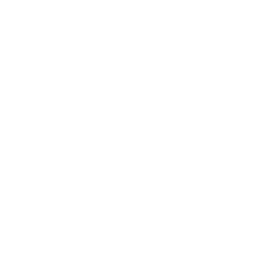
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">市场状态识别</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 量化金融 / 资产管理 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 摘要

本示例使用 **PROC ACECLUS** 寻找区分市场状态的潜在结构，然后据此进行聚类。基于 10 个市场特征的 100 个周度观测（股票收益与波动率、信用利差与高收益利差、2 年/10 年期收益率曲线、美元、大宗商品以及 VIX 变动），ACECLUS 在*不*使用任何状态标签的情况下估计出近似的状态内协方差，并沿各状态相互分离的方向导出典范变量。

在 P=0.02 阈值下，算法经两次迭代收敛并保留**三个典范维度**，它们共同解释了全部状态间离散（特征值占比为 57.8%、24.4%、17.8%）。更宽松的 P=0.05 阈值会过度平滑协方差，并**将结构坍缩为单一维度**——这提醒我们阈值会实质性地影响结果。

将这三个典范变量输入 **PROC FASTCLUS**（k=4），可对这 100 个周得到清晰的压力严重程度排序（整体 R² = 0.51，伪 F = 33.2）：一个 62 周的平静核心组、一个 22 周的复苏/波动率回落组、一个 12 周的压力升高组，以及一个 4 周的深度危机组（高收益利差平均约 1,514 bps）。这些归类结果被导出，用于下游的投资组合风险调节。


## 数据来源

| 来源 | 说明 | 记录数 |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | 跨资产类别的周度市场特征观测 | 100 |
| 变量：eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

该序列由一个五状态马尔可夫状态转换过程生成（牛市扩张、周期后段、避险、危机、复苏），各状态具有条件特征分布。在无许可证运行时，特征表被限制为前 100 个周度观测（约 2 年）——这是一个以牛市为主的窗口，其间也经历了一段短暂的危机与复苏。周度收益与水平变动代表周末价格走势；利差以基点计，波动率为 VIX 式指数。


---

In [1]:
/* --------------------------------------------------------
   生成一份每周多资产市场历史,其中嵌入了由马尔可夫
   切换过程驱动的五种状态。本示例在无许可证下运行,
   因此下面的特征表被限制在前 100 个周度观测(约 2 年)——
   一个以牛市为主、被短暂危机和复苏所打断的窗口。
   -------------------------------------------------------- */
数据 work.market_weekly;
    调用 streaminit(42);
    标签 regime_label='市场状态'
          eq_return_pct='股票周收益率(%)' eq_vol_idx='股票波动率指数'
          credit_spread_bps='信用利差(bps)' hy_spread_bps='高收益利差(bps)'
          yield_2y='2年期收益率' yield_10y='10年期收益率'
          term_spread='期限利差' usd_index_chg='美元指数变动'
          commodities_ret='商品收益率' vix_chg='VIX变动' week_id='周序号';
    /* 5 种状态:1=牛市, 2=周期后段, 3=避险, 4=危机, 5=复苏 */
    长度 regime_label $32;
    保留值 current_regime 1;
    循环 week_id = 1 到 5000;
        /* 马尔可夫状态切换 */
        u = rand('uniform');
        如果 current_regime = 1 那么 循环; /* 牛市:长期 */
            如果 u > 0.97 那么 current_regime = 2;
        结束;
        否则 如果 current_regime = 2 那么 循环; /* 周期后段 */
            如果 u > 0.92 那么 current_regime = 3;
        结束;
        否则 如果 current_regime = 3 那么 循环; /* 避险 */
            如果 u > 0.80 那么 current_regime = 4;
            否则 如果 u < 0.10 那么 current_regime = 1;
        结束;
        否则 如果 current_regime = 4 那么 循环; /* 危机:短暂 */
            如果 u > 0.75 那么 current_regime = 5;
        结束;
        否则 如果 current_regime = 5 那么 循环; /* 复苏 */
            如果 u > 0.85 那么 current_regime = 1;
        结束;
        如果 current_regime = 1 那么 regime_label = '牛市扩张';
        否则 如果 current_regime = 2 那么 regime_label = '周期后段';
        否则 如果 current_regime = 3 那么 regime_label = '避险资金外流';
        否则 如果 current_regime = 4 那么 regime_label = '危机';
        否则 regime_label = '复苏';
        /* 各状态条件下的特征分布 */
        如果 current_regime = 1 那么 循环;  /* 牛市 */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        结束;
        否则 如果 current_regime = 2 那么 循环;  /* 周期后段 */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        结束;
        否则 如果 current_regime = 3 那么 循环;  /* 避险 */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        结束;
        否则 如果 current_regime = 4 那么 循环;  /* 危机 */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        结束;
        否则 循环;  /* 复苏 */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        结束;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        如果 week_id = 1 那么 vix_chg = 0;
        输出;
    结束;
    删除 u;
    重命名 credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
运行;



NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.44 seconds
  cpu   1.44 seconds


---

In [2]:
/* --------------------------------------------------------
   各市场状态的基线特征分布
   -------------------------------------------------------- */
过程 均值 数据=work.market_weekly n mean std MIN MAX;
    分类 regime_label;
    变量 eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    标签 regime_label='市场状态'
          eq_return_pct='股票周收益率(%)' eq_vol_idx='股票波动率指数'
          credit_spread_bps='信用利差(bps)' hy_spread_bps='高收益利差(bps)'
          term_spread='期限利差' vix_chg='VIX变动';
    标题 '各市场状态的基线特征分布';
运行;


                                                      各市场状态的基线特征分布                                                      

                                                  The MEANS Procedure

                                Analysis Variable : eq_return_pct 股票周收益率(%)

        市场状态                        N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------
        危机                             12     -2.3403333      3.9436692     -8.0160000      3.7360000
        周期后段                           39      0.0364359      1.9733801     -4.6010000      3.7030000
        复苏                              4      0.0077500      1.5951747     -0.8330000      2.4000000
        牛市扩张                           28      0.2860000      1.0226518     -1.5980000      2.2150000
        避险资金外流                         17     -0.8447059      1.2832441     -3.3850000      1.1810000
        --------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                      各市场状态的基线特征分布                                                      




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


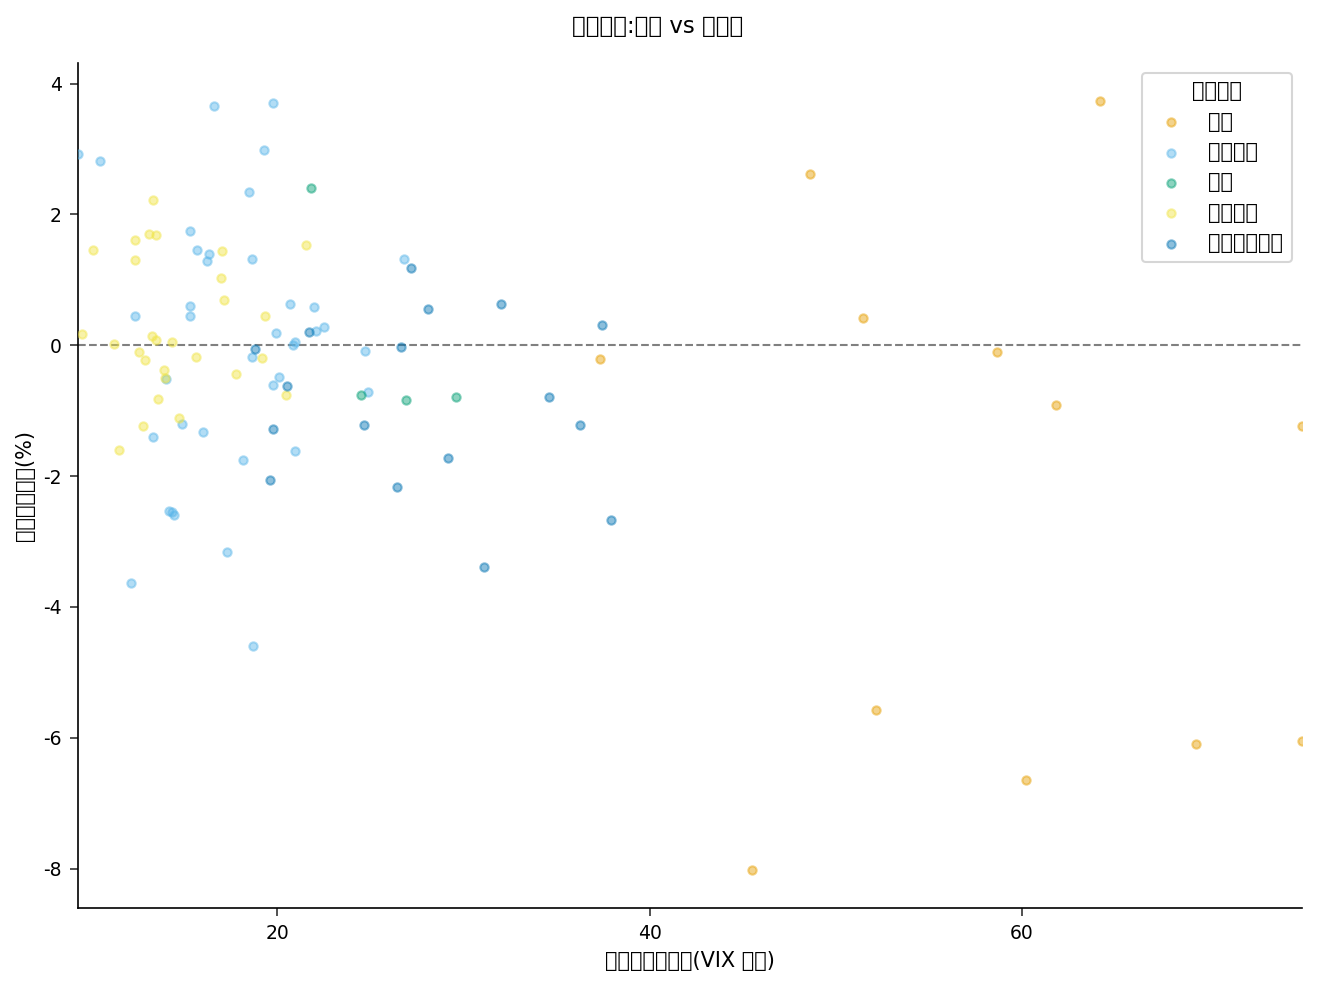

In [3]:
/* --------------------------------------------------------
   按市场状态划分的股票收益 vs 波动率指数
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS 标签='股票波动率指数(VIX 代理)';
    YAXIS 标签='股票周收益率(%)';
    keylegend / 标题='市场状态';
    标题 '市场状态:收益 vs 波动率';
运行;


---

In [4]:
/* --------------------------------------------------------
   近似的状态内协方差估计。
   ACECLUS 在不知道聚类标签的情况下估计合并的
   聚类内协方差,然后推导出可分离各状态的典范变量。
   P=0.02 设置成对距离阈值:只有最接近的约 2% 的
   观测对被视为同一状态。
   -------------------------------------------------------- */
过程 aceclus 数据=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    变量 eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    标题 '近似的状态内协方差估计 (P=0.02)';
运行;


                                                      各市场状态的基线特征分布                                                      

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
股票周收益率(%)                 -0.3298       2.1334
股票波动率指数                   23.7341      14.7118
信用利差(bps)                171.1000     118.0522
高收益利差(bps)               596.2100     341.1657
2年期收益率                     2.8713       1.4029
10年期收益率                    3.1472       1.0815
期限利差                       0.2697       0.9969
美元指数变动                    -0.0184       0.8046
商品收益率                     -0.3444       1.3444
VIX变动                      0.0036      10.


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   在 P=0.05 处的灵敏度检验——更宽松的同状态阈值
   会纳入更多的观测对,从而抬高估计的状态内协方差。
   将其典范结构(特征值与保留维度)与 P=0.02 的解
   进行比较。
   -------------------------------------------------------- */
过程 aceclus 数据=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    变量 eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    标题 '灵敏度检验 (P=0.05)';
运行;


                                                      各市场状态的基线特征分布                                                      

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
股票周收益率(%)                 -0.3298       2.1334
股票波动率指数                   23.7341      14.7118
信用利差(bps)                171.1000     118.0522
高收益利差(bps)               596.2100     341.1657
2年期收益率                     2.8713       1.4029
10年期收益率                    3.1472       1.0815
期限利差                       0.2697       0.9969
美元指数变动                    -0.0184       0.8046
商品收益率                     -0.3444       1.3444
VIX变动                      0.0036      10.


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   在 ACECLUS 典范变量上做 k 均值聚类。ACECLUS 保留了
   三个典范维度(Can1-Can3),因此聚类在这些维度上运行。
   四个聚类对应四个观测充分的市场状态。
   -------------------------------------------------------- */
过程 FASTCLUS 数据=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    变量 can1 can2 can3;
    标题 'ACECLUS 典范变量上的 k 均值聚类';
运行;


                                                      各市场状态的基线特征分布                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                                     状态聚类 vs 实际市场状态                                                     

                                                   The FREQ Procedure

Table of 聚类 by 市场状态

聚类     |                危机 |              周期后段 |                复苏 |              牛市扩张 |            避险资金外流 |              Total
-------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
1      |                 4 |                 2 |                 0 |                 2 |                 4 |                 12
       |              4.00 |              2.00 |              0.00 |              2.00 |              4.00 |              12.00
-------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------
2      |                 3 |                28 |                 3 |                21 |                 7 |                 62
       |          


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


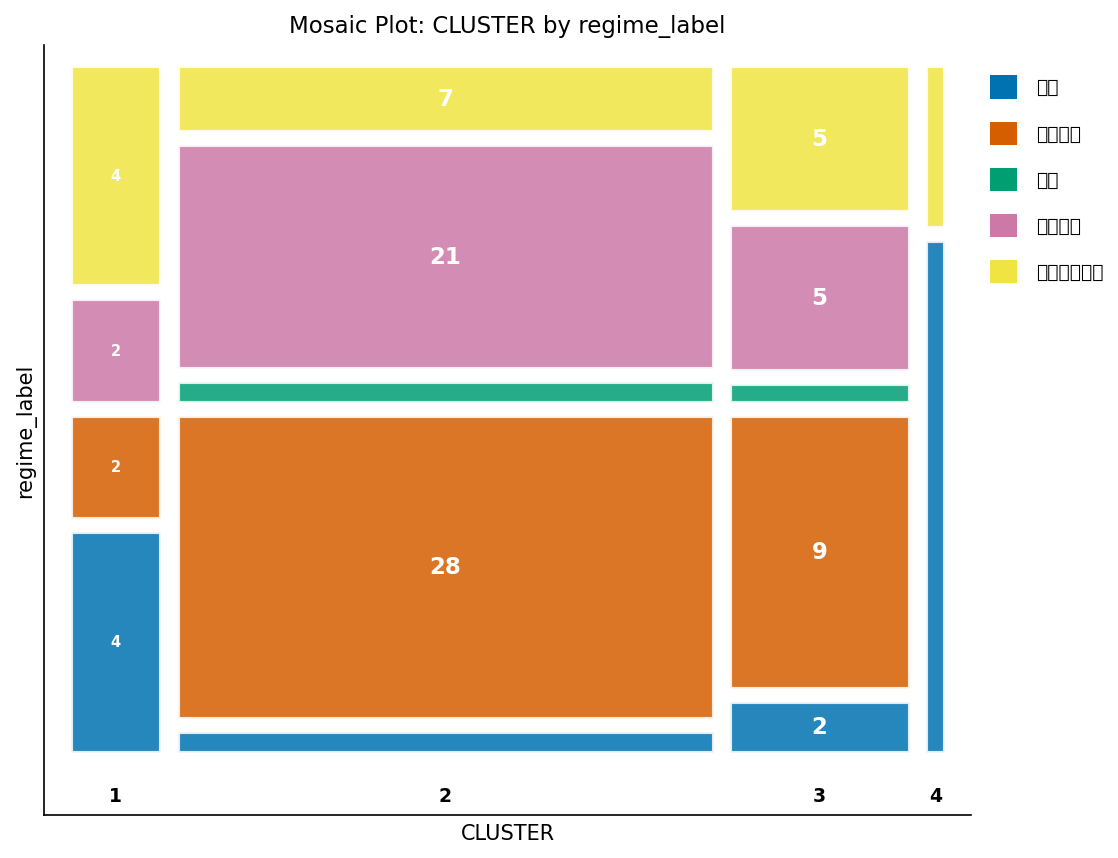

In [7]:
/* --------------------------------------------------------
   将分配的聚类与数据生成时已知的
   市场状态标签进行对照验证
   -------------------------------------------------------- */
过程 频率 数据=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    标签 CLUSTER='聚类' regime_label='市场状态';
    标题 '状态聚类 vs 实际市场状态';
运行;


In [8]:
/* --------------------------------------------------------
   为便于解释,画出各聚类的特征均值画像
   -------------------------------------------------------- */
过程 均值 数据=work.regime_assignments mean;
    分类 CLUSTER;
    变量 eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    标签 CLUSTER='聚类'
          eq_return_pct='股票周收益率(%)' eq_vol_idx='股票波动率指数'
          credit_spread_bps='信用利差(bps)' hy_spread_bps='高收益利差(bps)'
          term_spread='期限利差' vix_chg='VIX变动';
    标题 '各聚类的特征均值画像';
运行;


                                                       各聚类的特征均值画像                                                       

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct 股票周收益率(%)

                                                         N
                                             聚类        Obs            Mean
                                             -----------------------------
                                             1          12      -2.0955000
                                             2          62      -0.3638871
                                             3          22       0.7421364
                                             4           4      -0.4010000
                                             -----------------------------

                                             Analysis Variable : eq_vol_idx 股票波动率指数

                                               


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### 解读

**ACECLUS 典范结构。** 在 100 周样本上，PROC ACECLUS（P=0.02，阈值 = 2.578941）经两次迭代收敛，产生三个典范变量。它们对应 `Inv(ACE)*(COV-ACE)` 的特征值为 0.0219、0.0093 和 0.0067，即占比 57.8%、24.4% 和 17.8%（累计 100%）。第一典范轴承载主导的风险偏好/风险规避对比；第二和第三轴对其加以细化。由于股票波动率与利差特征强烈同向变动，ACECLUS 将这一共同变异纳入状态内协方差，使得典范轴反映的是真正的状态间分离，而非共同的量纲。

**阈值敏感性。** 在 P=0.05 下重新运行会将距离阈值提高到 2.899704，使 4,950 个观测对中的 4,949 个落入截断范围内。此时估计的状态内协方差几乎等于总协方差，典范结构**坍缩为单一维度**（一个特征值 0.0096，占 100%）。因此 P=0.02 与 P=0.05 的解在此*不可*互换——更宽松的阈值抹去了更精细的状态轴，所以对本样本而言，更严格的阈值是更具信息量的设定。

**在典范变量上聚类。** 对 Can1–Can3 运行 PROC FASTCLUS（k=4），得到整体 R² 为 0.5089，伪 F 为 33.16。Can2 承担了大部分区分工作（R² = 0.626），Can1 贡献中等（R² = 0.359），而 Can3 几乎没有贡献（R² = 0.000）——这与只有两个轴携带强信号相一致。四个聚类构成一条市场压力梯度：

| 聚类 | n | 平均股票收益 | 平均 VIX | 平均 HY 利差 | 平均 VIX 变动 | 解读 |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | 平静核心（牛市 / 周期后段） |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | 复苏中，波动率下降 |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | 压力升高，波动率飙升 |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | 深度危机，极端信用压力 |

**聚类与真实状态对比。** 交叉表显示聚类与五个生成标签并非一一对应——这在意料之中，因为在此样本规模下这些标签在特征空间中大量重叠。大的平静聚类（62）吸收了大部分牛市（21）和周期后段（28）周；深度危机聚类（4）几乎全部是最极端的危机周（4 个中有 3 个）。因此典范轴是按*严重程度*而非精确标签来组织各周的，这对风险调节而言是更具可操作性的信号。

**用途。** 导出的周度归类支持战术性调节：当各周向聚类 1 和 4 迁移时，降低风险敞口并拉长久期；当它们回到平静核心（聚类 2）或复苏组（聚类 3）时，重新增加风险敞口。


---

In [9]:
/* --------------------------------------------------------
   导出每周状态分配结果,用于组合风险模型的
   条件化与信号生成
   -------------------------------------------------------- */
过程 EXPORT 数据=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
运行;



NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>